<a href="https://colab.research.google.com/github/CorinaArreguez/AprendizajeAutomatico/blob/main/TP4_AA1_regresion_lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP4 AA1

**Corina Tatiana Arreguez**

#**Tarea: Aplicación de Regresión Lineal y Análisis de Importancia de Variables**  
**Objetivo**: Aplicar un modelo de regresión lineal a un dataset de su elección, evaluar su rendimiento e identificar las variables más relevantes para la predicción.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets/?Task=Regression&skip=0&take=10&sort=desc&orderBy=NumHits&search=  
   - Requisitos:  
     - Debe tener al menos 4 variables numéricas continuas (1 target, 3 o más features).  
     - Idealmente, que las features tengan distintas escalas o unidades ( no excluyente).
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:

🔸Para este trabajo utilicé el dataset “[Bike Sharing](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset)” del repositorio UCI Machine Learning Repository.

El objetivo del dataset es analizar cómo distintas variables climáticas y temporales afectan la cantidad de alquileres de bicicletas.

**Carga de librerías y dataset**

In [1]:
# @title
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

In [2]:
# @title
url = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"

import zipfile
import requests
from io import BytesIO

r = requests.get(url)

z = zipfile.ZipFile(BytesIO(r.content))

print(z.namelist())

['Readme.txt', 'day.csv', 'hour.csv']



## 2. **Análisis exploratorio (previo al modelado)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - **Pregunta clave**: ¿Qué relaciones lineales preliminares observan?  


## Resolución:

In [3]:
# @title
df = pd.read_csv(z.open('hour.csv'))

df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


🔸El archivo hour.csv contiene información horaria sobre el uso del sistema de bicicletas compartidas.

Algunas variables importantes:

🌡️temp: temperatura normalizada.

💧hum: humedad.

🍃windspeed: velocidad del viento.

🌄season: estación del año.

⛅weathersit: situación climática.

🔢cnt: cantidad total de bicicletas alquiladas. (variable objetivo)

In [4]:
# @title
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [5]:
# @title
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Histogramas**

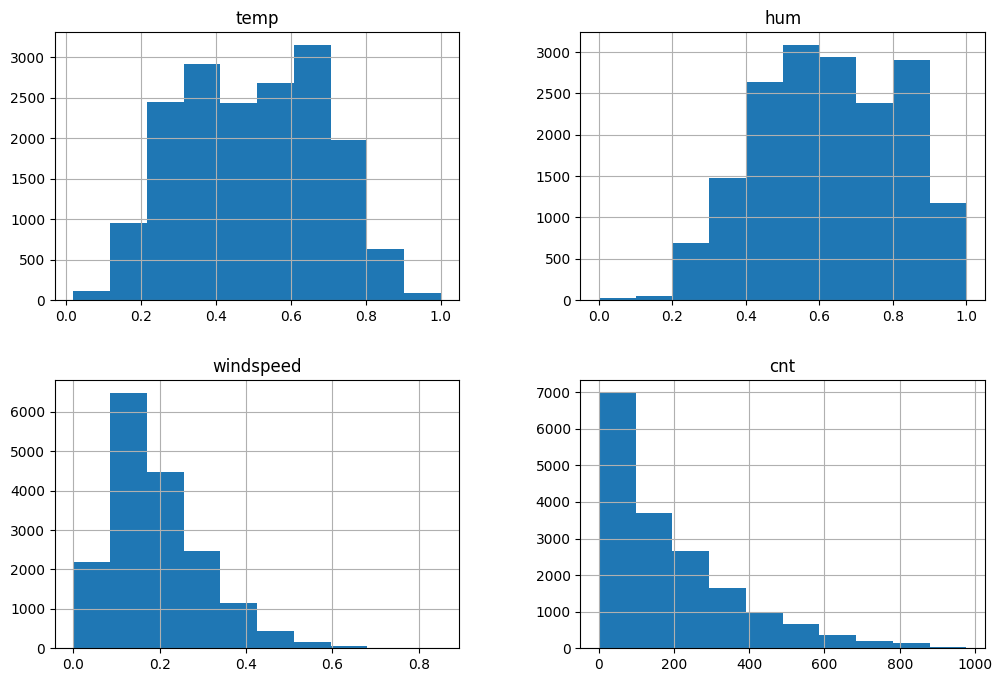

In [6]:
# @title
df[['temp', 'hum', 'windspeed', 'cnt']].hist(figsize=(12,8))
plt.show()

**Boxplots**

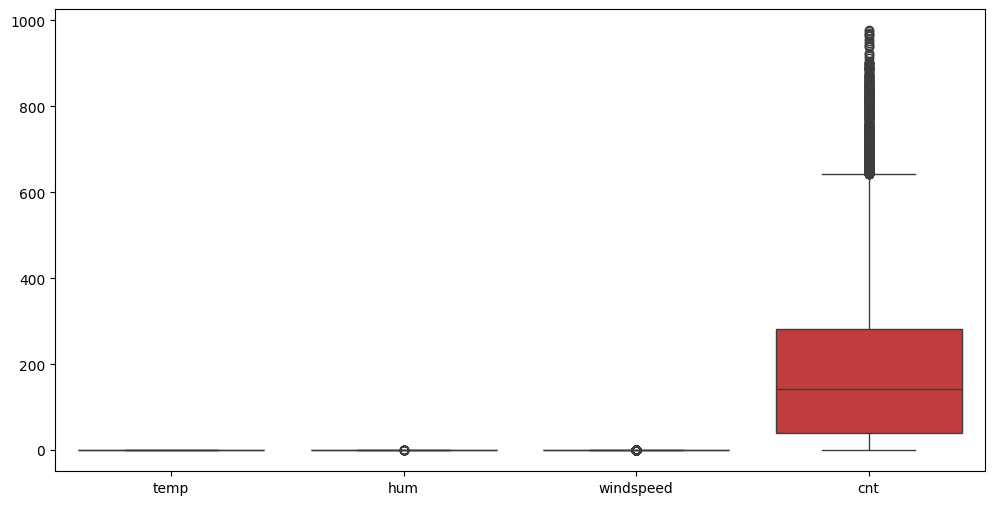

In [7]:
# @title
plt.figure(figsize=(12,6))

sns.boxplot(data=df[['temp', 'hum', 'windspeed', 'cnt']])

plt.show()

**Scatterplots**

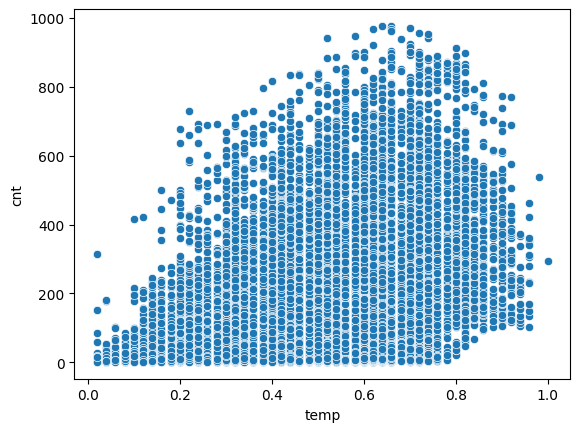

In [8]:
# @title
sns.scatterplot(data=df, x='temp', y='cnt')
plt.show()

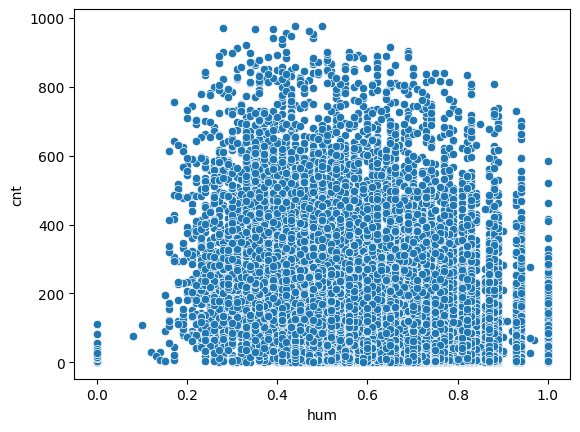

In [10]:
# @title
sns.scatterplot(data=df, x='hum', y='cnt')
plt.show()

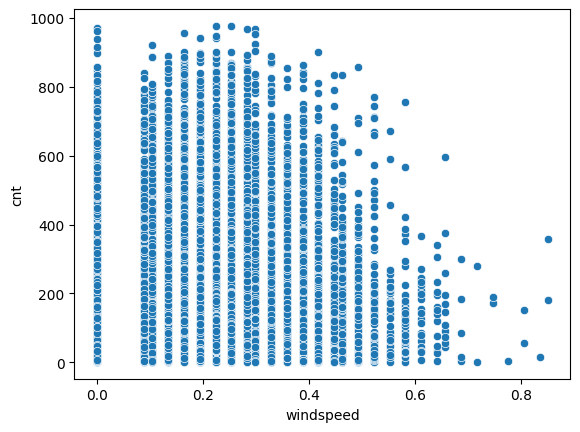

In [11]:
# @title
sns.scatterplot(data=df, x='windspeed', y='cnt')
plt.show()

🔸A partir de los gráficos de dispersión se observa que la temperatura presenta una relación positiva con la cantidad de alquileres. A medida que aumenta la temperatura, también tiende a aumentar la cantidad de bicicletas alquiladas.

En cambio, la humedad y la velocidad del viento parecen tener relaciones más débiles o negativas con la variable objetivo.

También se observan algunos outliers en la variable cnt, especialmente en valores altos de alquileres.

## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Escalen las features (p.ej., StandardScaler) para comparar coeficientes después.  
   - Dividan en train/test (70-30 o 80-20).  

## Resolución:

🔸En esta etapa se prepara el dataset verificando la existencia de valores faltantes, descartando variables no relevantes y escalando las variables numéricas para poder comparar correctamente los coeficientes del modelo.

Además, divido el dataset en conjuntos de entrenamiento y prueba.

In [12]:
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


🔸El dataset no presenta valores faltantes, por lo tanto no fue necesario aplicar técnicas de imputación o eliminación de registros

**Eliminar variables innecesarias**

In [13]:
df = df.drop(columns=['instant', 'dteday', 'casual', 'registered'])

🔸Se descartó la variable instant porque se trata únicamente de un identificador.

También se eliminó dteday ya que la información temporal ya se encuentra representada en otras variables como año, mes, día y hora.

Las variables casual y registered fueron descartadas porque su suma compone directamente la variable objetivo cnt, lo que produciría data leakage y un modelo artificialmente perfecto.

**Separar features y target**

In [14]:
X = df.drop('cnt', axis=1)
y = df['cnt']

**Train/Test Split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

🔸El dataset fue dividido en un 80% para entrenamiento y un 20% para prueba.

**Escalado de variables**

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

🔸Se aplicó StandardScaler para normalizar las variables y llevarlas a una escala comparable.

Esto permite interpretar de manera más adecuada los coeficientes de la regresión lineal, especialmente porque las variables originales poseen distintas unidades y rangos de valores.




## 4. **Regresión Lineal**  
   - Ajusten un modelo de regresión lineal (usando `sklearn.linear_model.LinearRegression`).  
   - Obtengan:  
     - Coeficientes (pesos) del modelo.  
     - Evaluar métricas en el set de entrenamiento y en el de testeo: **R²**, MSE (error cuadrático medio), MAE.  


## Resolución:

🔸El objetivo es predecir la cantidad total de bicicletas alquiladas (cnt) a partir de las variables del dataset.

**Entrenar el modelo**

In [17]:
modelo = LinearRegression()

modelo.fit(X_train_scaled, y_train)

LinearRegression()

**Predicciones**

In [18]:
y_train_pred = modelo.predict(X_train_scaled)

y_test_pred = modelo.predict(X_test_scaled)

**Métricas de entrenamiento**

In [19]:
r2_train = r2_score(y_train, y_train_pred)

mse_train = mean_squared_error(y_train, y_train_pred)

mae_train = mean_absolute_error(y_train, y_train_pred)

print("R² Train:", r2_train)
print("MSE Train:", mse_train)
print("MAE Train:", mae_train)

R² Train: 0.3888110962633091
MSE Train: 20292.648050152122
MAE Train: 106.55411541421637


**Métricas de test**

In [20]:
r2_test = r2_score(y_test, y_test_pred)

mse_test = mean_squared_error(y_test, y_test_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)

print("R² Test:", r2_test)
print("MSE Test:", mse_test)
print("MAE Test:", mae_test)

R² Test: 0.38798115831391333
MSE Test: 19379.82836765172
MAE Test: 104.80335089554426


**Coeficientes del modelo**

In [21]:
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
})

coeficientes

,Variable,Coeficiente
0,season,22.708848
1,yr,41.422089
2,mnth,0.409634
3,hr,52.960726
4,holiday,-4.026749
5,weekday,3.575328
6,workingday,1.821864
7,weathersit,-2.193186
8,temp,19.117295
9,atemp,35.320690


**Ordenar coeficientes por importancia**

In [22]:
coeficientes['Coeficiente_abs'] = coeficientes['Coeficiente'].abs()

coeficientes = coeficientes.sort_values(
    by='Coeficiente_abs',
    ascending=False
)

coeficientes

,Variable,Coeficiente,Coeficiente_abs
3,hr,52.960726,52.960726
1,yr,41.422089,41.422089
10,hum,-38.456281,38.456281
9,atemp,35.320690,35.320690
0,season,22.708848,22.708848
8,temp,19.117295,19.117295
11,windspeed,4.217798,4.217798
4,holiday,-4.026749,4.026749
5,weekday,3.575328,3.575328
7,weathersit,-2.193186,2.193186


**Visualización de coeficientes**

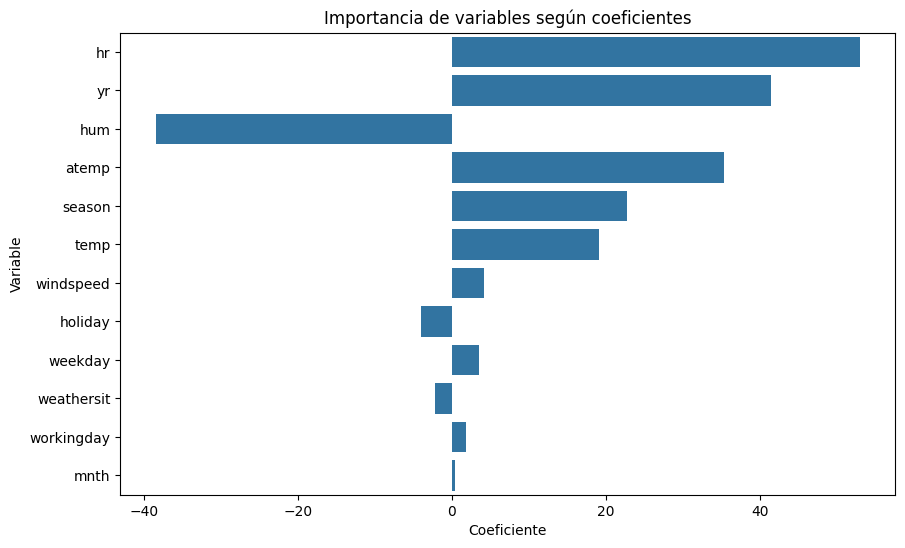

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=coeficientes,
    x='Coeficiente',
    y='Variable'
)

plt.title('Importancia de variables según coeficientes')

plt.show()

🔸El modelo de regresión lineal obtuvo un R² de aproximadamente 0.39 sobre el conjunto de prueba.

Esto significa que el modelo logra explicar cerca del 39% de la variabilidad de la cantidad de bicicletas alquiladas (cnt).

El valor de MAE fue aproximadamente 104.8, lo que indica que, en promedio, las predicciones del modelo se desvían alrededor de 105 bicicletas respecto al valor real.

Por otro lado, el MSE obtenido fue de 19379.83, reflejando el error cuadrático promedio de las predicciones.

Si bien el modelo no alcanza un rendimiento extremadamente alto, logra capturar parcialmente la relación entre las variables climáticas y temporales con la cantidad de alquileres.


## 5. **Importancia de Variables**  
   - Analicen los **coeficientes** del modelo:  
     - Valores absolutos altos → mayor impacto en el target.  
     - Signo: Relación positiva/negativa con el target.  
   - Comparen la magnitud de los coeficientes **escalados** (si usaron features en distintas unidades).  
   - **5.1. Opcional**:
     Otra forma es "desordenar" un feature y ver cómo empeora el modelo. Si al desordenarlo el error aumenta mucho, ese feature era importante. Usen métodos como:  
     - **Permutation Importance** (de sklearn) para validar importancia. Más info en https://scikit-learn.org/stable/modules/permutation_importance.html



## Resolución:

🔸Las variables más importantes según el valor absoluto de sus coeficientes fueron:

-hr (hora del día)

-yr (año)

-hum (humedad)

-atemp (temperatura percibida)

-season

La variable hr fue la que presentó el mayor impacto en la predicción, lo cual indica que la cantidad de alquileres cambia significativamente según la hora del día.

También se observa que la variable yr tiene un coeficiente positivo importante, lo que podría indicar un aumento en el uso del sistema de bicicletas con el paso del tiempo.

En cambio, la humedad (hum) presenta un coeficiente negativo, sugiriendo que niveles altos de humedad reducen la cantidad de alquileres.

Tanto la temperatura (temp) como la temperatura percibida (atemp) tienen relaciones positivas con la variable objetivo, indicando que las personas tienden a alquilar más bicicletas cuando el clima es más agradable.

**5.1 Permutation Importance**

In [24]:
resultado = permutation_importance(
    modelo,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42
)

importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': resultado.importances_mean
})

importancia = importancia.sort_values(
    by='Importancia',
    ascending=False
)

importancia

,Variable,Importancia
3,hr,0.183209
1,yr,0.101521
10,hum,0.093422
9,atemp,0.081311
0,season,0.027278
8,temp,0.024438
11,windspeed,0.001991
5,weekday,0.000857
4,holiday,0.000506
6,workingday,0.000186


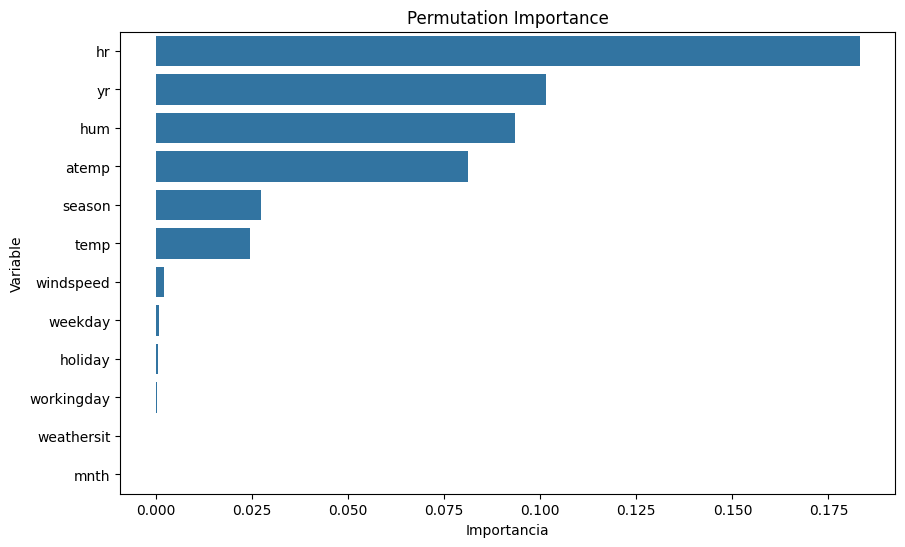

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importancia,
    x='Importancia',
    y='Variable'
)

plt.title('Permutation Importance')

plt.show()

🔸Se utilizó el método Permutation Importance para validar la relevancia de las variables.

Este método consiste en desordenar aleatoriamente cada feature y medir cuánto empeora el rendimiento del modelo.

Las variables cuya alteración produce una mayor caída en el desempeño son consideradas más importantes para la predicción.


## 6. **Reflexión**  
   - ¿Cuáles variables son más importantes según el modelo? ¿Coincide con su análisis exploratorio?  
   - ¿El modelo tiene buen rendimiento (R² alto, MSE bajo)? Si no, ¿a qué podría deberse?  



## Resolución:

🔸Las variables más importantes identificadas por el modelo fueron la hora del día (hr), el año (yr), la humedad (hum) y la temperatura percibida (atemp).

Estos resultados coinciden en gran medida con el análisis exploratorio realizado previamente, donde se observó que las condiciones climáticas y temporales tenían relación con la cantidad de bicicletas alquiladas.

El modelo obtuvo un rendimiento moderado, con un R² cercano a 0.39. Esto indica que la regresión lineal logra explicar parte del comportamiento del target, aunque existen otros factores no contemplados o relaciones no lineales que afectan la predicción.

Una posible mejora sería utilizar modelos más complejos, como Random Forest o XGBoost, que pueden capturar relaciones no lineales entre las variables.

En general, el trabajo permitió comprender mejor el proceso completo de construcción de un modelo de regresión, incluyendo análisis exploratorio, preprocesamiento, entrenamiento y análisis de importancia de variables.


## **Bonus**:  
- Prueben eliminar variables "poco importantes" y reentrenar el modelo. ¿Mejora el rendimiento?  


---

### **Tips**:  
- Si el R² es muy bajo, revisen si hay relaciones no lineales (y consideren transformar features).  
- Documenten cada paso: ¡la trazabilidad es clave en ciencia de datos!  
- Al final de su trabajo debe crear un apartado de REFERENCIAS para citar todo recurso utilizado. Si usó IA, debe


**Referencias**

-Documentación oficial de Scikit-learn: [Scikit-learn](https://scikit-learn.org/stable/)

-Dataset utilizado: [Bike Sharing](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset)

-Documentación de Pandas: [Pandas](https://pandas.pydata.org/docs/)

-Se utilizó IA generativa (chat gpt, gemini) como apoyo para consultas sobre interpretación de métricas, estructura del análisis y asistencia en fragmentos de código Python.